## Random Forest Classifer

### Import the pickle file

In [2]:
import pickle
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.metrics import mean_squared_error, r2_score, precision_score, recall_score, RocCurveDisplay, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, RandomizedSearchCV


with open('finaldataset.pkl', 'rb') as f:
    data = pickle.load(f)


In [3]:
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

### Random Forest Model

In [4]:
clf = RandomForestClassifier(n_estimators=100, 
                            random_state=42,
                            max_depth=10,
                            n_jobs=6)
clf.fit(X_train, y_train)

c:\Users\micah\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=10, n_jobs=6, random_state=42)

In [5]:
## predict the model
clf = clf.fit(X_train,y_train)
y_train_hat = clf.predict(X_train)
y_test_hat = clf.predict(X_test)

c:\Users\micah\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [6]:
clf.score(X_train, y_train), clf.score(X_test, y_test)

(0.8748515204307887, 0.8687096646474245)

In [7]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
    }

dtc = RandomForestClassifier(random_state=42, 
                             max_samples = .5)            
sh = RandomizedSearchCV(dtc, 
                         param_grid,
                         n_iter = 50,
                         cv=3, 
                         scoring = 'accuracy', 
                         verbose = 1,
                         n_jobs= -1,    
                         random_state = 42).fit(X_train, y_train)
sh.best_estimator_


c:\Users\micah\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=50. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 32 candidates, totalling 96 fits


c:\Users\micah\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(max_depth=20, max_samples=0.5, n_estimators=200,
                       random_state=42)

In [8]:
clf = sh.best_estimator_
y_train_hat = clf.predict(X_train)
y_test_hat = clf.predict(X_test)

clf.score(X_train, y_train), clf.score(X_test, y_test)

(0.912377256889452, 0.8739359385516886)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_test_hat))
print("Precision:", precision_score(y_test, y_test_hat, average='binary'))
print("Recall:", recall_score(y_test, y_test_hat, average='binary'))
print("F1 Score:", classification_report(y_test, y_test_hat))


Accuracy: 0.8739359385516886
Precision: 0.7822374039282665
Recall: 0.23823146944083226
F1 Score:               precision    recall  f1-score   support

           0       0.88      0.99      0.93     21412
           1       0.78      0.24      0.37      3845

    accuracy                           0.87     25257
   macro avg       0.83      0.61      0.65     25257
weighted avg       0.86      0.87      0.84     25257



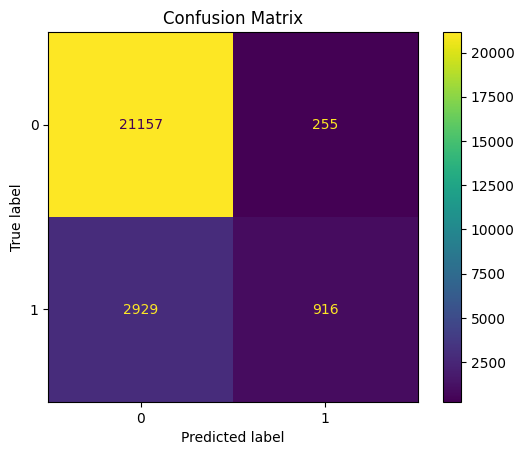

In [10]:
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [11]:
scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validated accuracy scores:", scores)
print("Average cross-validated accuracy:", scores.mean())

c:\Users\micah\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\micah\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\micah\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\micah\miniconda3\envs\misy331_base\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed whe

Cross-validated accuracy scores: [0.87404108 0.87681267 0.87334818 0.87557535 0.87383686]
Average cross-validated accuracy: 0.8747228293676217


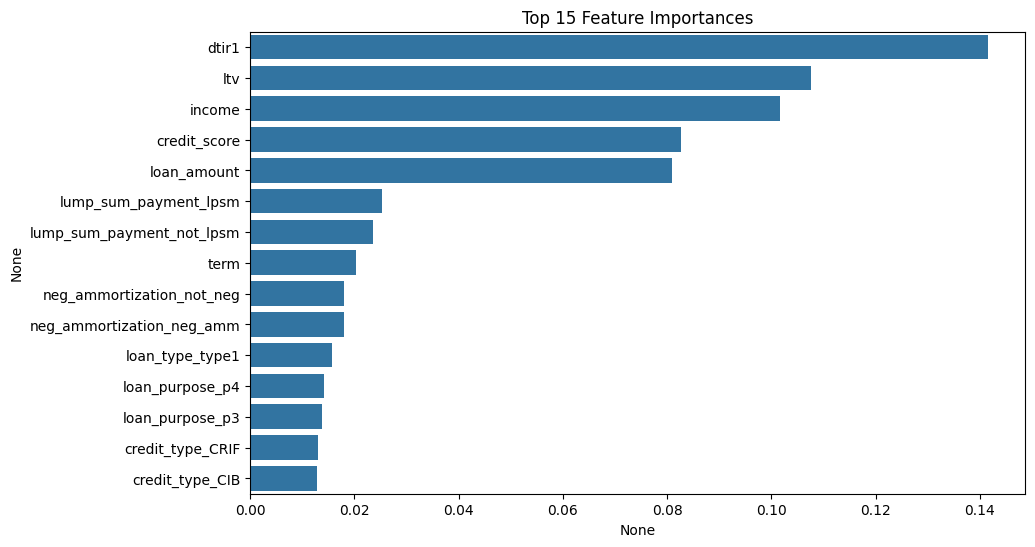

In [12]:
importances = clf.feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp[:15], y=feat_imp.index[:15])
plt.title("Top 15 Feature Importances")
plt.show()

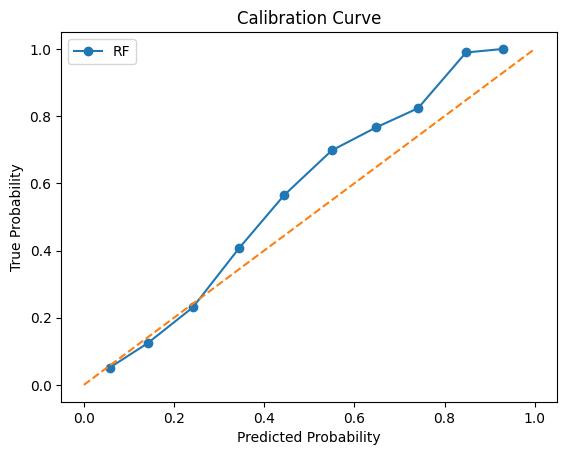

In [13]:
from sklearn.calibration import calibration_curve


y_proba = clf.predict_proba(X_test)[:, 1] 
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)


plt.plot(prob_pred, prob_true, marker='o', label='RF')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.legend()
plt.show()

In [14]:
overlap = pd.merge(X_train, X_test, how='inner')
print(f"Overlapping rows: {len(overlap)}")

Overlapping rows: 0
